In [1]:
import warnings
warnings.filterwarnings("ignore")

In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve,auc
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score
from imblearn.over_sampling import SMOTE


In [13]:
file_path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1028-Skin-Disorder-Prediction-20220512T101734Z-001 (1)\PRCP-1028-Skin-Disorder-Prediction\dataset_35_dermatology.csv"


In [14]:
df = pd.read_csv(file_path)


In [15]:
df.columns


Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_in_the_infiltrate', 'PNL_infiltrate',
       'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis',
       'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges',
       'elongation_of_the_rete_ridges',
       'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_of_the_granular_layer',
       'vacuolisation_and_damage_of_basal_layer', 'spongiosis',
       'saw-tooth_appearance_of_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_monoluclear_inflitrate',
       'band-like_infiltrate', 'Age', 'class'],
      dtype='object')

In [16]:
df.tail()


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3
365,3,2,2,0,0,0,0,0,3,3,...,2,0,0,0,0,0,3,0,35,1


In [17]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                            366 non-

In [18]:
df.isnull().sum()


erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

In [19]:
df['Age'].unique()


array(['55', '8', '26', '40', '45', '41', '18', '57', '22', '30', '20',
       '21', '10', '65', '38', '23', '17', '51', '42', '44', '33', '43',
       '50', '34', '?', '15', '46', '62', '35', '48', '12', '52', '60',
       '32', '19', '29', '25', '36', '13', '27', '31', '28', '64', '39',
       '47', '16', '0', '7', '70', '37', '61', '67', '56', '53', '24',
       '58', '49', '63', '68', '9', '75'], dtype=object)

In [20]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')


In [21]:
df['Age'] = df['Age'].fillna(df['Age'].mean())


In [22]:
df.isnull().sum()
df.dtypes


erythema                                      int64
scaling                                       int64
definite_borders                              int64
itching                                       int64
koebner_phenomenon                            int64
polygonal_papules                             int64
follicular_papules                            int64
oral_mucosal_involvement                      int64
knee_and_elbow_involvement                    int64
scalp_involvement                             int64
family_history                                int64
melanin_incontinence                          int64
eosinophils_in_the_infiltrate                 int64
PNL_infiltrate                                int64
fibrosis_of_the_papillary_dermis              int64
exocytosis                                    int64
acanthosis                                    int64
hyperkeratosis                                int64
parakeratosis                                 int64
clubbing_of_

In [23]:
X = df.drop(columns=['class'])
y = df['class']


In [24]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [25]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [26]:


smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [27]:

model = LogisticRegression(
    max_iter=1000,
    multi_class='ovr'
)

model.fit(X_train_smote, y_train_smote)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'ovr'


In [36]:
y_pred = model.predict(X_test)

In [37]:
y_prob = model.predict_proba(X_test)[:, 1]  # Probability of positive class

In [38]:
# Display accuracy as percentage
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")


Accuracy: 95.95%


In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.91      0.83      0.87        12
           3       1.00      1.00      1.00        15
           4       0.82      0.90      0.86        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.96        74
   macro avg       0.95      0.96      0.95        74
weighted avg       0.96      0.96      0.96        74



In [34]:


feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(model.coef_).mean(axis=0)
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)


,Feature,Importance
4,koebner_phenomenon,0.972357
14,fibrosis_of_the_papillary_dermis,0.896797
13,PNL_infiltrate,0.740612
27,spongiosis,0.693473
25,disappearance_of_the_granular_layer,0.671973
20,elongation_of_the_rete_ridges,0.612049
3,itching,0.611255
19,clubbing_of_the_rete_ridges,0.516089
21,thinning_of_the_suprapapillary_epidermis,0.515293
30,perifollicular_parakeratosis,0.498567


In [45]:
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)


In [46]:
y_prob = model.predict_proba(X_test)


In [47]:
# Flatten all classes into one
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
roc_auc = auc(fpr, tpr)


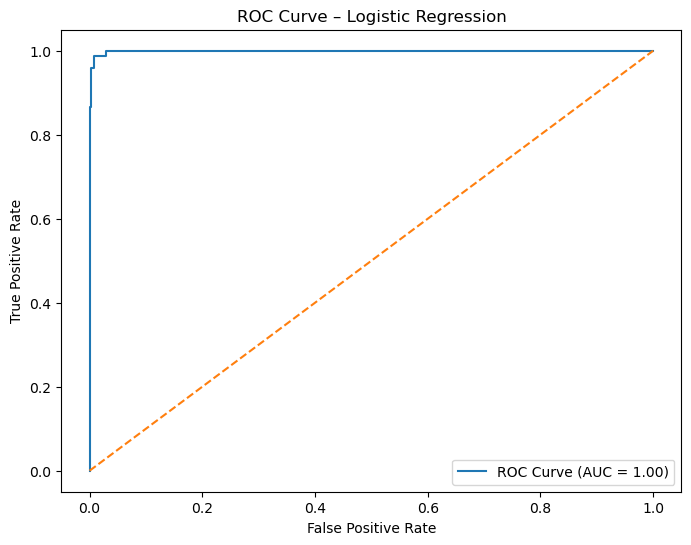

In [48]:
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.show()


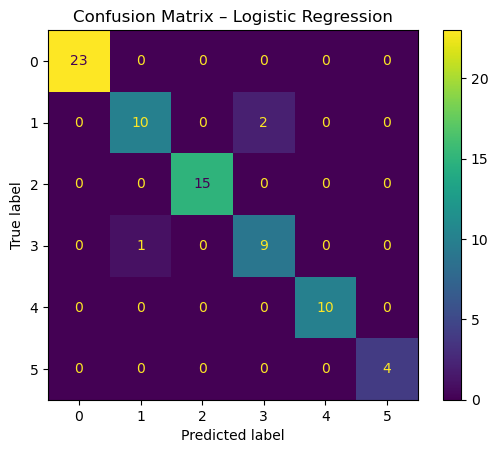

In [49]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix – Logistic Regression")
plt.show()


In [50]:
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)


In [51]:
y_prob = model.predict_proba(X_test)


In [52]:
precision, recall, _ = precision_recall_curve(
    y_test_bin.ravel(),
    y_prob.ravel()
)

avg_precision = average_precision_score(
    y_test_bin,
    y_prob,
    average="macro"
)


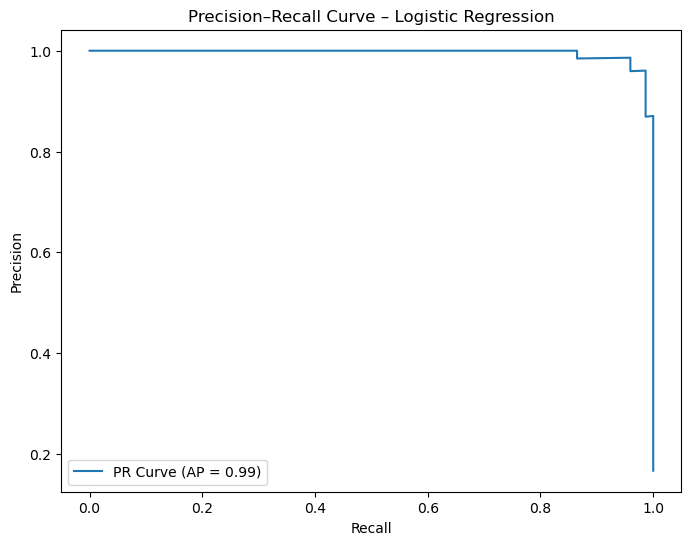

In [53]:
plt.figure(figsize=(8, 6))

plt.plot(recall, precision, label=f'PR Curve (AP = {avg_precision:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Logistic Regression")
plt.legend()
plt.show()


In [42]:
## SVM

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE

In [59]:
file_path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1028-Skin-Disorder-Prediction-20220512T101734Z-001 (1)\PRCP-1028-Skin-Disorder-Prediction\dataset_35_dermatology.csv"

df = pd.read_csv(file_path)


In [60]:
df.columns


Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_in_the_infiltrate', 'PNL_infiltrate',
       'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis',
       'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges',
       'elongation_of_the_rete_ridges',
       'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_of_the_granular_layer',
       'vacuolisation_and_damage_of_basal_layer', 'spongiosis',
       'saw-tooth_appearance_of_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_monoluclear_inflitrate',
       'band-like_infiltrate', 'Age', 'class'],
      dtype='object')

In [61]:
df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [62]:
df.replace('?', np.nan, inplace=True)


In [63]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'] = df['Age'].fillna(df['Age'].mean())


In [64]:
print("Missing values per column:\n", df.isnull().sum())


Missing values per column:
 erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinni

In [65]:
df = df.astype(int)


In [66]:
print("\nData types:\n", df.dtypes)



Data types:
 erythema                                    int64
scaling                                     int64
definite_borders                            int64
itching                                     int64
koebner_phenomenon                          int64
polygonal_papules                           int64
follicular_papules                          int64
oral_mucosal_involvement                    int64
knee_and_elbow_involvement                  int64
scalp_involvement                           int64
family_history                              int64
melanin_incontinence                        int64
eosinophils_in_the_infiltrate               int64
PNL_infiltrate                              int64
fibrosis_of_the_papillary_dermis            int64
exocytosis                                  int64
acanthosis                                  int64
hyperkeratosis                              int64
parakeratosis                               int64
clubbing_of_the_rete_ridges         

In [67]:
df['class'] = df['class'].apply(lambda x: 1 if x in [1, 2] else 0)


In [68]:
X = df.drop(columns=['class'])
y = df['class']


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [70]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [73]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [75]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_res, y_train_res)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [76]:
y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]


In [77]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")


Accuracy: 98.65%


In [78]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        39
           1       1.00      0.97      0.99        35

    accuracy                           0.99        74
   macro avg       0.99      0.99      0.99        74
weighted avg       0.99      0.99      0.99        74



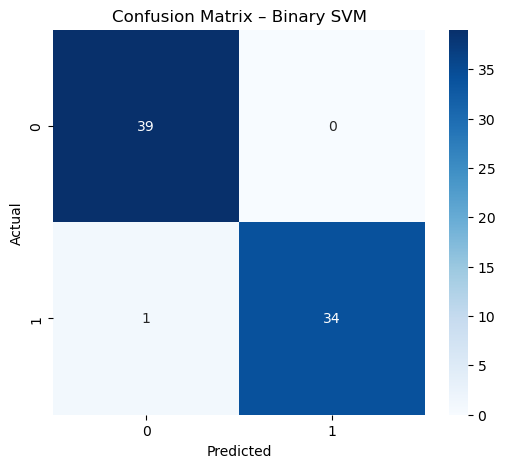

In [79]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Binary SVM")
plt.show()

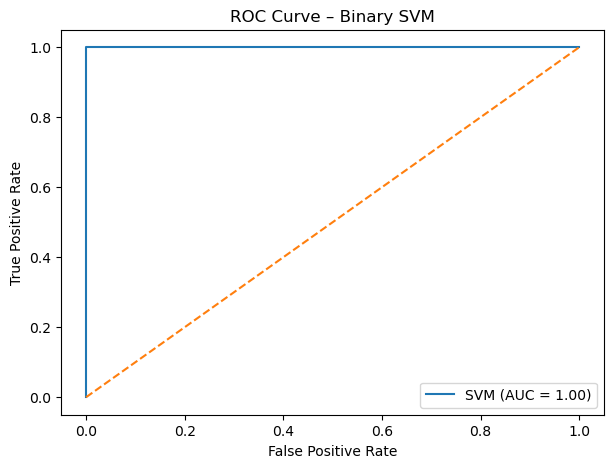

In [80]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Binary SVM")
plt.legend()
plt.show()

In [81]:
result = permutation_importance(
    svm_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

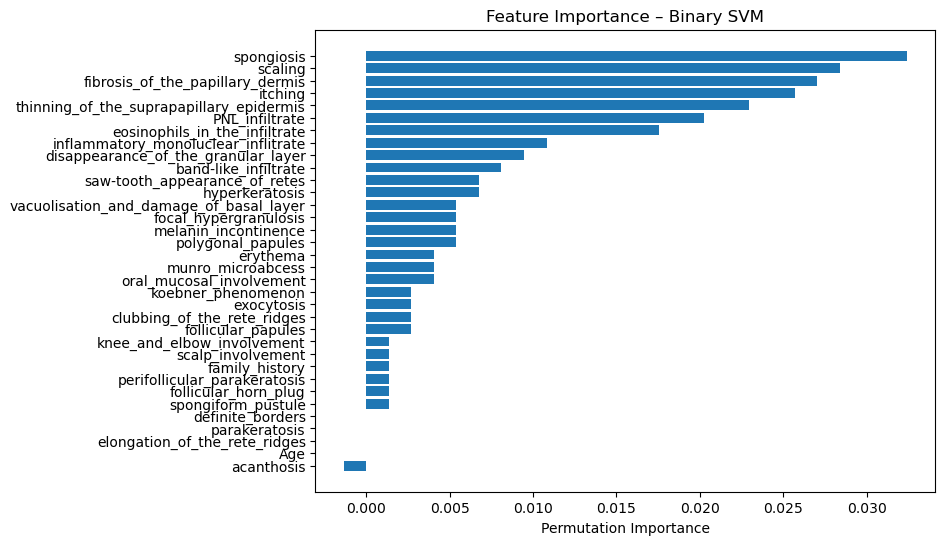

In [103]:
plt.figure(figsize=(8, 6))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.xlabel("Permutation Importance")
plt.title("Feature Importance – Binary SVM")
plt.gca().invert_yaxis()
plt.show()

In [83]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", feature_importance)



Feature Importance:
                                      Feature  Importance
14          fibrosis_of_the_papillary_dermis    0.035135
3                                    itching    0.032432
27                                spongiosis    0.024324
21  thinning_of_the_suprapapillary_epidermis    0.024324
13                            PNL_infiltrate    0.022973
4                         koebner_phenomenon    0.022973
1                                    scaling    0.017568
12             eosinophils_in_the_infiltrate    0.017568
0                                   erythema    0.012162
31       inflammatory_monoluclear_inflitrate    0.012162
25       disappearance_of_the_granular_layer    0.009459
18                             parakeratosis    0.006757
28             saw-tooth_appearance_of_retes    0.006757
17                            hyperkeratosis    0.006757
24                     focal_hypergranulosis    0.005405
26   vacuolisation_and_damage_of_basal_layer    0.005405
5        

In [84]:
# Random forest tree

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE


In [86]:
file_path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1028-Skin-Disorder-Prediction-20220512T101734Z-001 (1)\PRCP-1028-Skin-Disorder-Prediction\dataset_35_dermatology.csv"

df = pd.read_csv(file_path)


In [87]:
print("First 5 rows:")
print(df.head())


First 5 rows:
   erythema  scaling  definite_borders  itching  koebner_phenomenon  \
0         2        2                 0        3                   0   
1         3        3                 3        2                   1   
2         2        1                 2        3                   1   
3         2        2                 2        0                   0   
4         2        3                 2        2                   2   

   polygonal_papules  follicular_papules  oral_mucosal_involvement  \
0                  0                   0                         0   
1                  0                   0                         0   
2                  3                   0                         3   
3                  0                   0                         0   
4                  2                   0                         2   

   knee_and_elbow_involvement  scalp_involvement  ...  \
0                           1                  0  ...   
1                       

In [88]:
df.replace('?', np.nan, inplace=True)


In [89]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')


In [90]:
df['Age'] = df['Age'].fillna(df['Age'].mean())


In [91]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinni

In [92]:
df = df.astype(int)

In [93]:
print("\nData types:")
print(df.dtypes)



Data types:
erythema                                    int64
scaling                                     int64
definite_borders                            int64
itching                                     int64
koebner_phenomenon                          int64
polygonal_papules                           int64
follicular_papules                          int64
oral_mucosal_involvement                    int64
knee_and_elbow_involvement                  int64
scalp_involvement                           int64
family_history                              int64
melanin_incontinence                        int64
eosinophils_in_the_infiltrate               int64
PNL_infiltrate                              int64
fibrosis_of_the_papillary_dermis            int64
exocytosis                                  int64
acanthosis                                  int64
hyperkeratosis                              int64
parakeratosis                               int64
clubbing_of_the_rete_ridges          

In [94]:
df['class'] = df['class'].apply(lambda x: 1 if x in [1, 2] else 0)

X = df.drop(columns=['class'])
y = df['class']

In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [96]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nClass distribution after SMOTE:")
print(y_train_smote.value_counts())



Class distribution after SMOTE:
class
0    154
1    154
Name: count, dtype: int64


In [97]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,          # limits overfitting
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)


,n_estimators,100
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [98]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]


In [100]:
accuracy = accuracy_score(y_test, y_pred) * 100
print(f" Accuracy: {accuracy:.2f}%")

 Accuracy: 93.24%


In [101]:

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        39
           1       0.94      0.91      0.93        35

    accuracy                           0.93        74
   macro avg       0.93      0.93      0.93        74
weighted avg       0.93      0.93      0.93        74



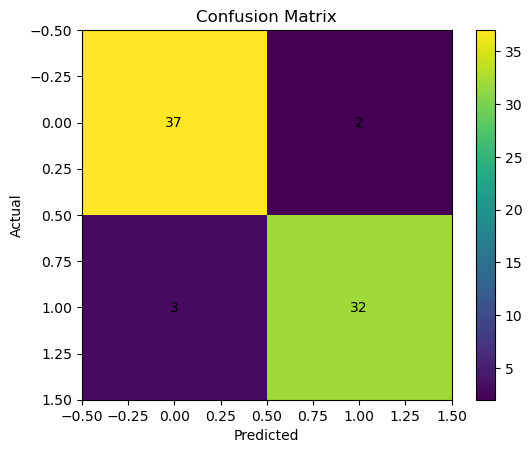

In [102]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

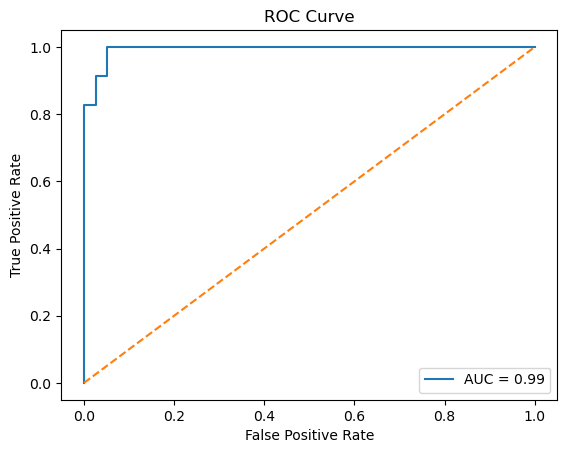

In [104]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

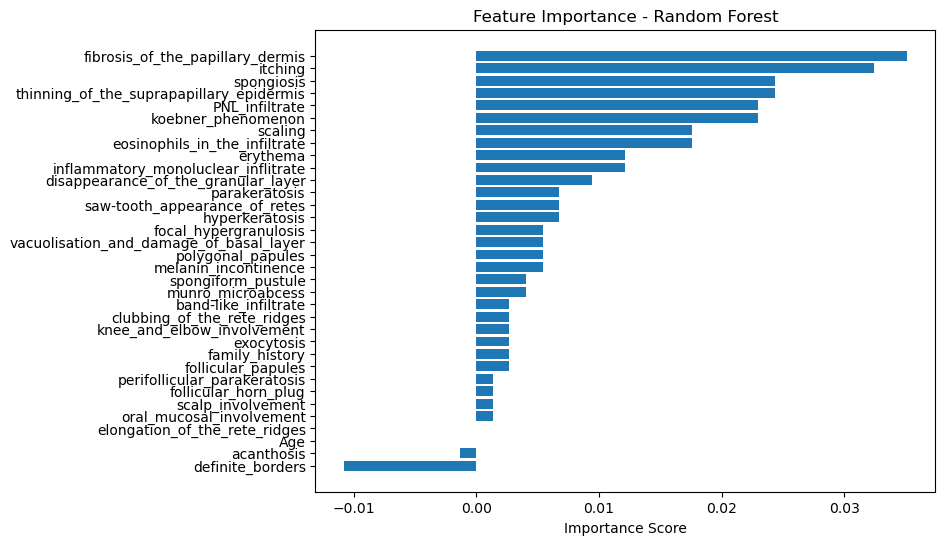

In [105]:
plt.figure(figsize=(8, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

In [106]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop Feature Importances:")
print(feature_importance.head(10))


Top Feature Importances:
                                     Feature  Importance
13                            PNL_infiltrate    0.216268
21  thinning_of_the_suprapapillary_epidermis    0.097090
19               clubbing_of_the_rete_ridges    0.092655
14          fibrosis_of_the_papillary_dermis    0.056462
9                          scalp_involvement    0.054299
23                         munro_microabcess    0.049801
4                         koebner_phenomenon    0.044524
1                                    scaling    0.032980
15                                exocytosis    0.029768
24                     focal_hypergranulosis    0.027755


In [1]:
# Xgboost

In [107]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import ( accuracy_score,classification_report,  confusion_matrix,roc_curve, auc)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


In [108]:
file_path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1028-Skin-Disorder-Prediction-20220512T101734Z-001 (1)\PRCP-1028-Skin-Disorder-Prediction\dataset_35_dermatology.csv"

df = pd.read_csv(file_path)


In [109]:
print("First 5 rows:")
print(df.head())


First 5 rows:
   erythema  scaling  definite_borders  itching  koebner_phenomenon  \
0         2        2                 0        3                   0   
1         3        3                 3        2                   1   
2         2        1                 2        3                   1   
3         2        2                 2        0                   0   
4         2        3                 2        2                   2   

   polygonal_papules  follicular_papules  oral_mucosal_involvement  \
0                  0                   0                         0   
1                  0                   0                         0   
2                  3                   0                         3   
3                  0                   0                         0   
4                  2                   0                         2   

   knee_and_elbow_involvement  scalp_involvement  ...  \
0                           1                  0  ...   
1                       

In [110]:
print("\nData types:")
print(df.dtypes)



Data types:
erythema                                     int64
scaling                                      int64
definite_borders                             int64
itching                                      int64
koebner_phenomenon                           int64
polygonal_papules                            int64
follicular_papules                           int64
oral_mucosal_involvement                     int64
knee_and_elbow_involvement                   int64
scalp_involvement                            int64
family_history                               int64
melanin_incontinence                         int64
eosinophils_in_the_infiltrate                int64
PNL_infiltrate                               int64
fibrosis_of_the_papillary_dermis             int64
exocytosis                                   int64
acanthosis                                   int64
hyperkeratosis                               int64
parakeratosis                                int64
clubbing_of_the_re

In [111]:
df.replace('?', np.nan, inplace=True)

In [112]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

In [113]:
print("\nMissing values before imputation:")
print(df.isnull().sum())


Missing values before imputation:
erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0

In [114]:
df['class'] = df['class'].apply(lambda x: 1 if x in [1, 2] else 0)


In [115]:
X = df.drop(columns=['class'])
y = df['class']

In [116]:
imputer = SimpleImputer(strategy='mean')

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print("\nMissing values after imputation:")
print(X_imputed.isnull().sum())


Missing values after imputation:
erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0


In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [118]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [119]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled, y_train
)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Class distribution after SMOTE:
class
0    154
1    154
Name: count, dtype: int64


In [120]:

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_smote, y_train_smote)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [121]:
y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

In [122]:
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"SVM Accuracy: {accuracy:.2f}%")

SVM Accuracy: 94.59%


In [123]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        39
           1       0.97      0.91      0.94        35

    accuracy                           0.95        74
   macro avg       0.95      0.94      0.95        74
weighted avg       0.95      0.95      0.95        74




Confusion Matrix:
[[38  1]
 [ 3 32]]


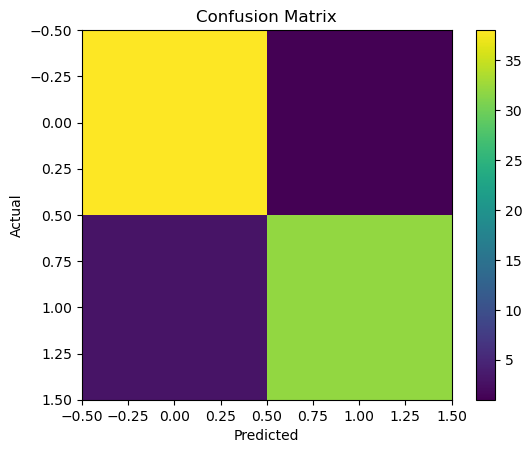

In [70]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Feature Importance:
                                     Feature  Importance
23                         munro_microabcess    0.159851
21  thinning_of_the_suprapapillary_epidermis    0.147973
13                            PNL_infiltrate    0.114947
24                     focal_hypergranulosis    0.090657
11                      melanin_incontinence    0.063906
22                        spongiform_pustule    0.048493
30              perifollicular_parakeratosis    0.043961
28             saw-tooth_appearance_of_retes    0.040026
19               clubbing_of_the_rete_ridges    0.037334
6                         follicular_papules    0.034328
14          fibrosis_of_the_papillary_dermis    0.033954
4                         koebner_phenomenon    0.030531
27                                spongiosis    0.021377
32                      band-like_infiltrate    0.019493
16                                acanthosis    0.015286
1                                    scaling    0.014776
0         

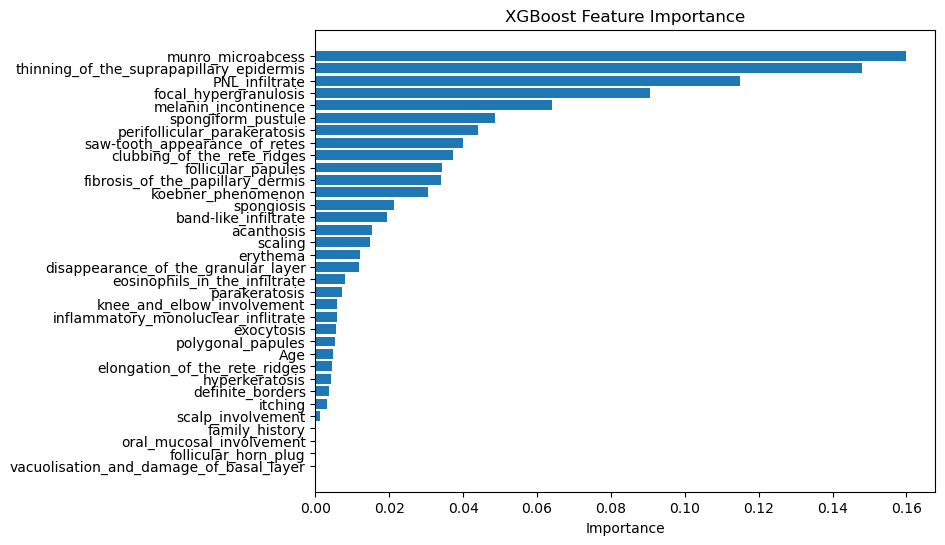

In [71]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(8, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()

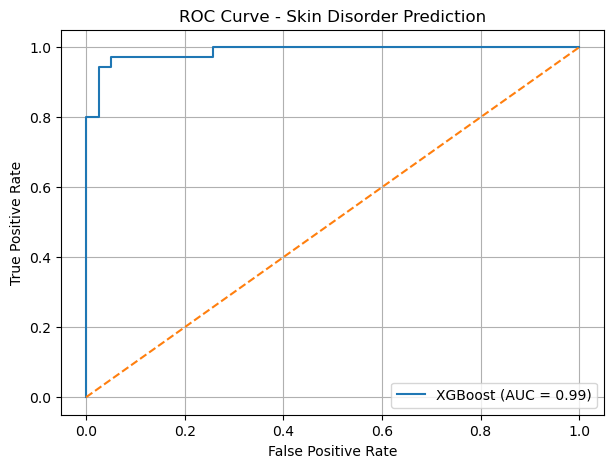

In [72]:

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Skin Disorder Prediction')
plt.legend(loc='lower right')
plt.grid()
plt.show()


In [ ]:
## Decision Tree

In [124]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import label_binarize
import seaborn as sns


In [125]:
file_path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1028-Skin-Disorder-Prediction-20220512T101734Z-001 (1)\PRCP-1028-Skin-Disorder-Prediction\dataset_35_dermatology.csv"

df = pd.read_csv(file_path)

In [126]:
print("First 5 rows:")
print(df.head())


First 5 rows:
   erythema  scaling  definite_borders  itching  koebner_phenomenon  \
0         2        2                 0        3                   0   
1         3        3                 3        2                   1   
2         2        1                 2        3                   1   
3         2        2                 2        0                   0   
4         2        3                 2        2                   2   

   polygonal_papules  follicular_papules  oral_mucosal_involvement  \
0                  0                   0                         0   
1                  0                   0                         0   
2                  3                   0                         3   
3                  0                   0                         0   
4                  2                   0                         2   

   knee_and_elbow_involvement  scalp_involvement  ...  \
0                           1                  0  ...   
1                       

In [127]:
df.replace('?', np.nan, inplace=True)

In [128]:
df = df.apply(pd.to_numeric)


In [129]:
X = df.drop(columns=['class'])
y = df['class']

In [130]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [131]:
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [132]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


In [133]:
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,          # control overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [134]:
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)

In [135]:
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"SVM Accuracy: {accuracy:.2f}%")

SVM Accuracy: 90.54%


In [139]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           1       1.00      0.91      0.95        23
           2       0.71      0.83      0.77        12
           3       1.00      0.93      0.97        15
           4       0.89      0.80      0.84        10
           5       0.91      1.00      0.95        10
           6       0.80      1.00      0.89         4

    accuracy                           0.91        74
   macro avg       0.89      0.91      0.90        74
weighted avg       0.92      0.91      0.91        74



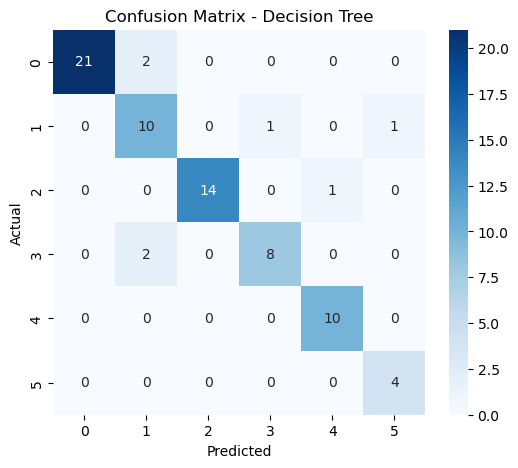

In [140]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


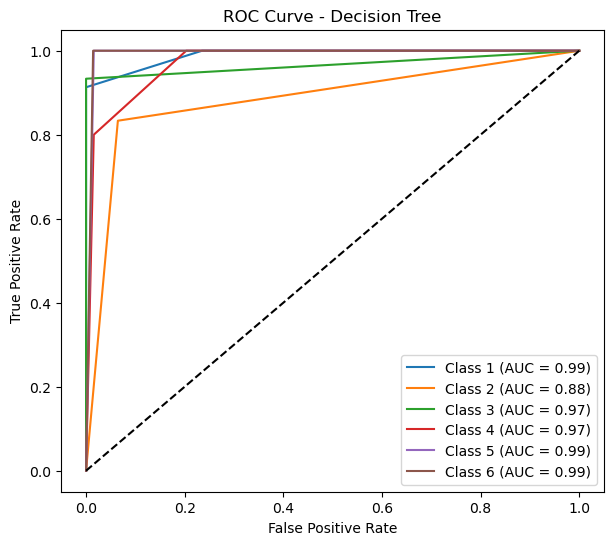

In [141]:
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(7,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend()
plt.show()


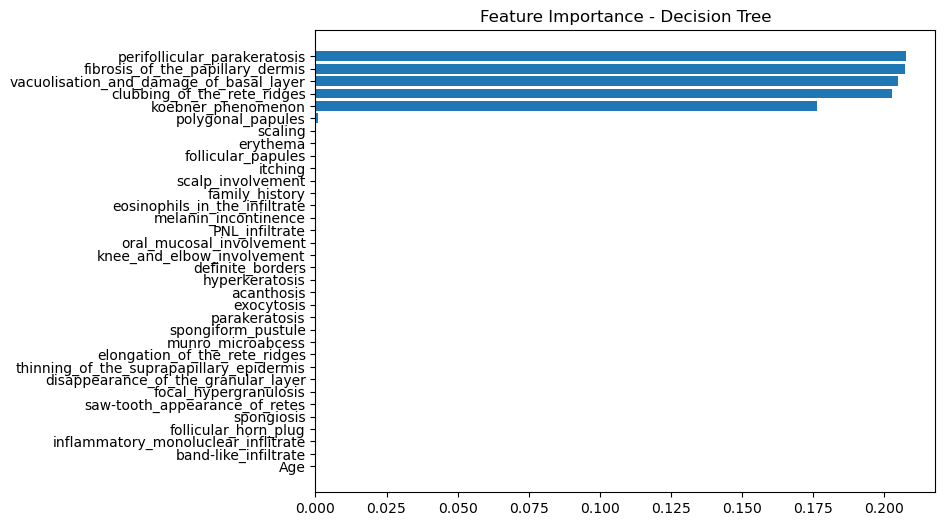

In [142]:
importances = dt.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
plt.barh(feat_df['Feature'], feat_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Decision Tree")
plt.show()

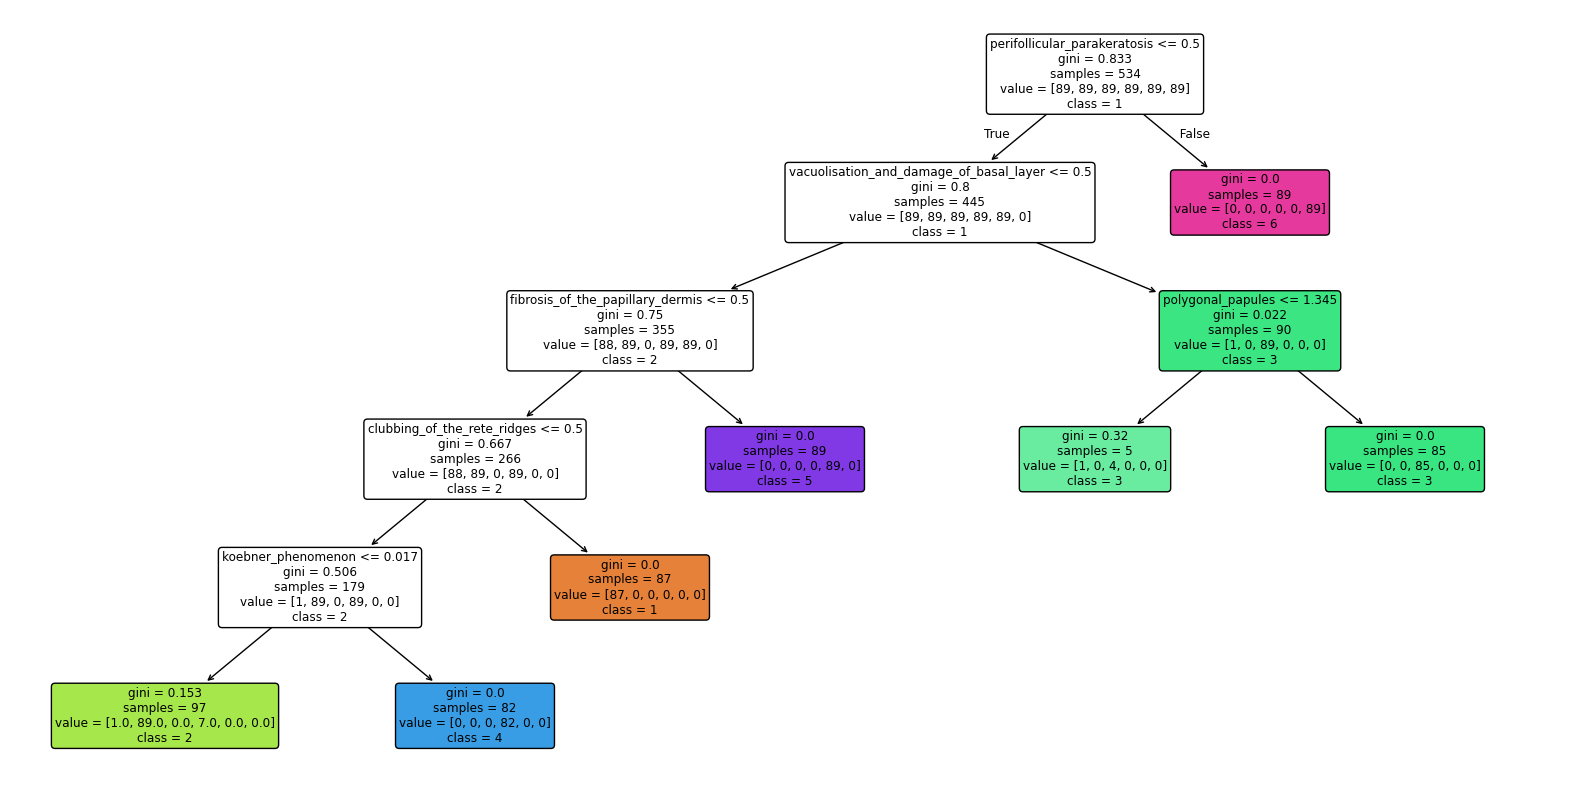

In [143]:
plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=feature_names,
    class_names=[str(c) for c in classes],
    filled=True,
    rounded=True
)
plt.show()

In [144]:
## K-Nearest Neighbors (KNN)

In [145]:
from sklearn.neighbors import KNeighborsClassifier


In [146]:
import seaborn as sns


In [175]:
k_values = list(range(1, 22))
accuracy_list = []

print("K Value  |  Accuracy (%)")
print("------------------------")

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean'
    )
    knn.fit(X_train_smote, y_train_smote)
    y_pred = knn.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    accuracy_list.append(acc)
    
    print(f"{k:<8} |  {acc * 100:.2f}")

K Value  |  Accuracy (%)
------------------------
1        |  89.19
2        |  91.89
3        |  89.19
4        |  90.54
5        |  89.19
6        |  90.54
7        |  87.84
8        |  89.19
9        |  87.84
10       |  87.84
11       |  87.84
12       |  89.19
13       |  87.84
14       |  89.19
15       |  87.84
16       |  89.19
17       |  89.19
18       |  89.19
19       |  87.84
20       |  87.84
21       |  89.19


In [176]:
best_k = k_values[np.argmax(accuracy_list)]
best_accuracy = max(accuracy_list)

print("\nBest K:", best_k)
print(f"Best Accuracy: {best_accuracy * 100:.2f}%")


Best K: 2
Best Accuracy: 91.89%


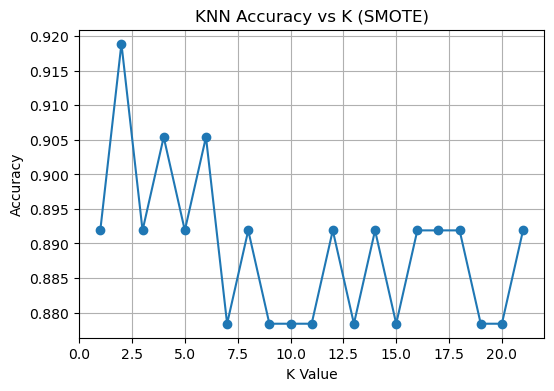

In [177]:
plt.figure(figsize=(6,4))
plt.plot(k_values, accuracy_list, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K (SMOTE)")
plt.grid(True)
plt.show()

In [178]:
knn_best = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean'
)

In [179]:
knn_best.fit(X_train_smote, y_train_smote)

y_pred = knn_best.predict(X_test)
y_prob = knn_best.predict_proba(X_test)[:, 1]


In [180]:
print(f"Final KNN Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")


Final KNN Accuracy: 91.89%


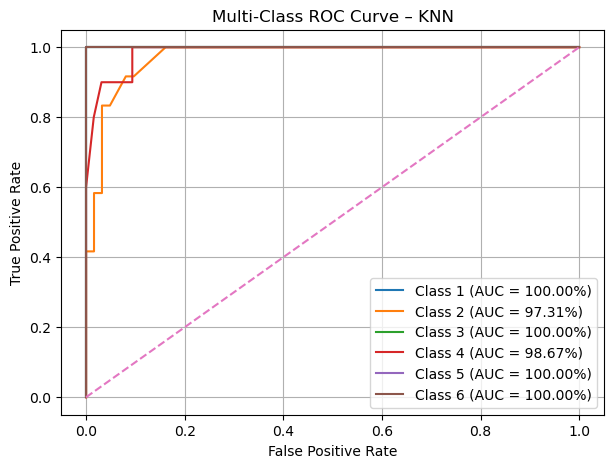

Overall ROC-AUC: 99.33%


In [183]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Binarize labels
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# Predict probabilities
y_prob = knn.predict_proba(X_test)

# Compute ROC for each class
plt.figure(figsize=(7,5))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {cls} (AUC = {roc_auc*100:.2f}%)')

# Random guess line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve – KNN')
plt.legend()
plt.grid()
plt.show()

# Overall ROC-AUC
overall_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
print(f"Overall ROC-AUC: {overall_auc*100:.2f}%")


In [336]:
# Naive Bayes

In [484]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [485]:
file_path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1028-Skin-Disorder-Prediction-20220512T101734Z-001 (1)\PRCP-1028-Skin-Disorder-Prediction\dataset_35_dermatology.csv"
df = pd.read_csv(file_path)

In [486]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'].fillna(df['Age'].mean(), inplace=True)


In [487]:
classes = np.unique(y_train_res)
y_train_bin = label_binarize(y_train_res, classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)

In [488]:
X = df.drop(columns=['class'])
y = df['class']

In [489]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [490]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [491]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [492]:
gnb = GaussianNB()
gnb.fit(X_train_res, y_train_res)

,priors,None
,var_smoothing,1e-09


In [493]:
y_pred = gnb.predict(X_test_scaled)


In [494]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%")

Accuracy: 86.49%


In [495]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           1       0.96      1.00      0.98        23
           2       1.00      0.25      0.40        12
           3       1.00      1.00      1.00        15
           4       0.53      0.90      0.67        10
           5       1.00      1.00      1.00        10
           6       0.80      1.00      0.89         4

    accuracy                           0.86        74
   macro avg       0.88      0.86      0.82        74
weighted avg       0.91      0.86      0.85        74


Confusion Matrix:
 [[23  0  0  0  0  0]
 [ 0  3  0  8  0  1]
 [ 0  0 15  0  0  0]
 [ 1  0  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


In [502]:
y_prob = gnb.predict_proba(X_test_scaled)


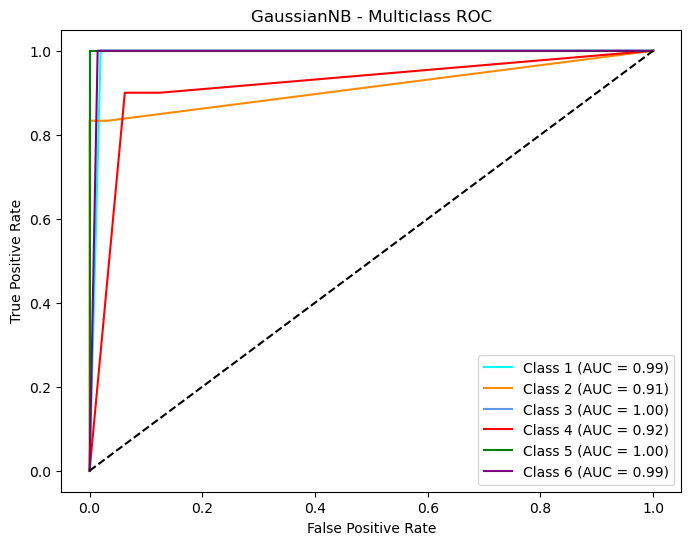

In [503]:

# Compute ROC curve and ROC AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for idx, c in enumerate(classes):
    fpr[idx], tpr[idx], _ = roc_curve(y_test_bin[:, idx], y_prob[:, idx])
    roc_auc[idx] = auc(fpr[idx], tpr[idx])

# Plotting in the style you want
plt.figure(figsize=(8,6))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple'])
for i, color in zip(range(len(classes)), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'Class {classes[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('GaussianNB - Multiclass ROC')
plt.legend(loc='lower right')
plt.show()

In [395]:
# BERNOULLI NAIVE BAYES

In [504]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Binarizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from itertools import cycle

In [505]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'].fillna(df['Age'].mean(), inplace=True)

In [506]:
X = df.drop(columns=['class'])
y = df['class']

In [507]:
binarizer = Binarizer(threshold=0)
X_bin = binarizer.fit_transform(X)

In [508]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y, test_size=0.2, random_state=42, stratify=y
)

In [509]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [510]:
bnb = BernoulliNB()
bnb.fit(X_train_smote, y_train_smote)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [511]:
y_pred = bnb.predict(X_test)
y_prob = bnb.predict_proba(X_test)

In [512]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%")

Accuracy: 97.30%


In [513]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.92      0.92      0.92        12
           3       1.00      1.00      1.00        15
           4       0.90      0.90      0.90        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.97        74
   macro avg       0.97      0.97      0.97        74
weighted avg       0.97      0.97      0.97        74



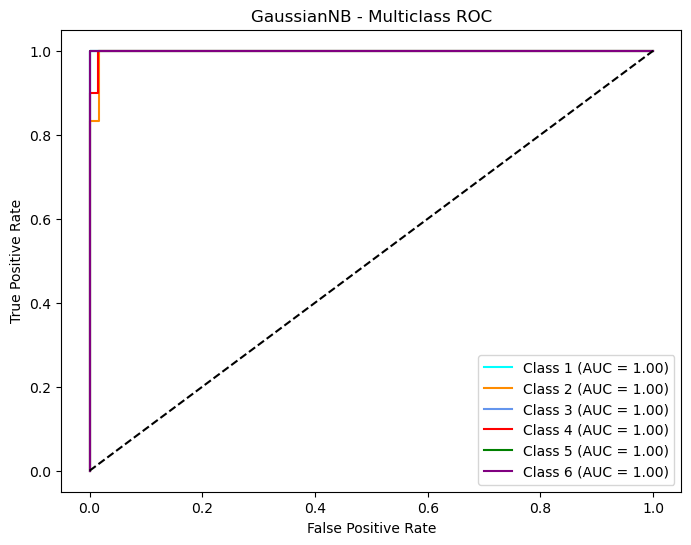

In [514]:
fpr = dict()
tpr = dict()
roc_auc = dict()
for idx, c in enumerate(classes):
    fpr[idx], tpr[idx], _ = roc_curve(y_test_bin[:, idx], y_prob[:, idx])
    roc_auc[idx] = auc(fpr[idx], tpr[idx])

# Plotting in the style you want
plt.figure(figsize=(8,6))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple'])
for i, color in zip(range(len(classes)), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'Class {classes[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('GaussianNB - Multiclass ROC')
plt.legend(loc='lower right')
plt.show()

In [515]:
# Multinomial Naive Bayes

In [516]:
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [517]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [518]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [519]:
nb_model = MultinomialNB()
nb_model.fit(X_train_res, y_train_res)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [520]:
y_pred = nb_model.predict(X_test)
y_prob = nb_model.predict_proba(X_test)[:, 1]

In [521]:
acc = accuracy_score(y_test, y_pred)
print(f"MultinomialNB Accuracy: {acc * 100:.2f}%")

MultinomialNB Accuracy: 97.30%


In [522]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      0.83      0.91        12
           3       1.00      1.00      1.00        15
           4       0.91      1.00      0.95        10
           5       1.00      1.00      1.00        10
           6       0.80      1.00      0.89         4

    accuracy                           0.97        74
   macro avg       0.95      0.97      0.96        74
weighted avg       0.98      0.97      0.97        74


Confusion Matrix:
 [[23  0  0  0  0  0]
 [ 0 10  0  1  0  1]
 [ 0  0 15  0  0  0]
 [ 0  0  0 10  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


In [525]:
y_prob = gnb.predict_proba(X_test_scaled)


In [526]:
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

fpr = dict()
tpr = dict()
roc_auc = dict()
for i, c in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

In [527]:
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(classes)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= len(classes)
roc_auc["macro"] = auc(all_fpr, mean_tpr)

print("ROC-AUC (macro):", roc_auc["macro"])

ROC-AUC (macro): 0.8307687676059123


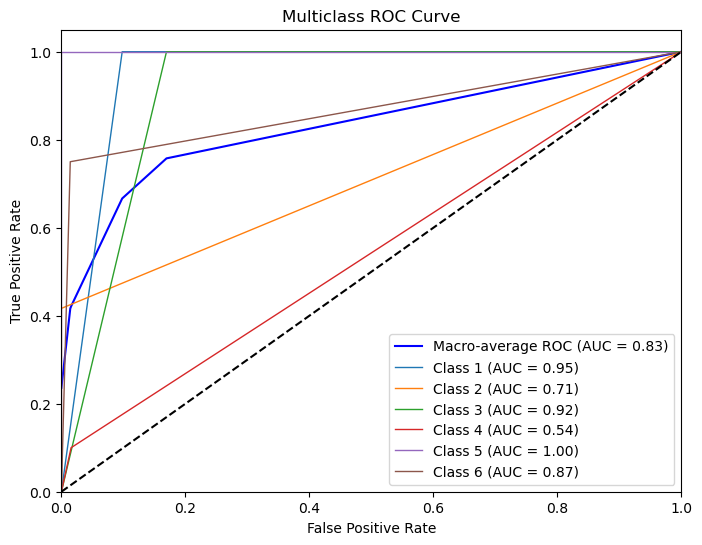

In [528]:
plt.figure(figsize=(8,6))
plt.plot(all_fpr, mean_tpr, color='b', label='Macro-average ROC (AUC = %0.2f)' % roc_auc["macro"])
for i, c in enumerate(classes):
    plt.plot(fpr[i], tpr[i], lw=1, label=f'Class {c} (AUC = {roc_auc[i]:0.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [ ]:
## REPORT 

In [535]:
from IPython.display import display, Markdown

report_text = """
# **Skin Disorder Prediction Analysis Report**

---

## **Dataset Overview**
- **Number of Features:** 34 (33 clinical/histopathological + 1 Age)  
- **Target Classes:** 6 types of erythemato-squamous diseases  
  - Psoriasis  
  - Seborrheic Dermatitis  
  - Lichen Planus  
  - Pityriasis Rosea  
  - Chronic Dermatitis  
  - Pityriasis Rubra Pilaris  
- **Dataset Source:** [PRCP-1028 Skin Disorder Prediction](https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1028-Skin-Disorder-Prediction-20220512T101734Z-001.zip)  
- **Domain:** Healthcare  

---

## **Clinical Attributes (11)**
1. **erythema** – Redness of the skin  
2. **scaling** – Flaking or peeling of skin  
3. **definite borders** – Clear edges of skin lesions  
4. **itching** – Sensation causing desire to scratch  
5. **koebner phenomenon** – Skin lesions at sites of trauma  
6. **polygonal papules** – Small, raised, polygon-shaped bumps  
7. **follicular papules** – Papules around hair follicles  
8. **oral mucosal involvement** – Lesions in mouth mucosa  
9. **knee and elbow involvement** – Lesions on knees and elbows  
10. **scalp involvement** – Lesions on scalp  
11. **family history** – Presence of similar diseases in family (0 = No, 1 = Yes)  

---

## **Histopathological Attributes (22)**
12. **melanin incontinence** – Leakage of melanin from epidermis to dermis  
13. **eosinophils in the infiltrate** – Presence of eosinophils in tissue  
14. **PNL infiltrate** – Polymorphonuclear leukocytes infiltration  
15. **fibrosis of the papillary dermis** – Thickening of dermal connective tissue  
16. **exocytosis** – Movement of inflammatory cells into the epidermis  
17. **acanthosis** – Epidermal thickening  
18. **hyperkeratosis** – Thickening of stratum corneum  
19. **parakeratosis** – Retention of nuclei in stratum corneum  
20. **clubbing of the rete ridges** – Widened epidermal projections  
21. **elongation of the rete ridges** – Lengthening of epidermal ridges  
22. **thinning of the suprapapillary epidermis** – Reduced thickness above dermal papillae  
23. **spongiform pustule** – Pustules formed in epidermis  
24. **munro microabcess** – Small collections of neutrophils in stratum corneum  
25. **focal hypergranulosis** – Localized thickening of granular layer  
26. **disappearance of the granular layer** – Loss of granular layer in epidermis  
27. **vacuolisation and damage of basal layer** – Cell damage at epidermal base  
28. **spongiosis** – Intercellular edema in epidermis  
29. **saw-tooth appearance of retes** – Distorted epidermal ridges  
30. **follicular horn plug** – Keratin plug in hair follicle  
31. **perifollicular parakeratosis** – Retained nuclei around follicles  
32. **inflammatory mononuclear infiltrate** – Lymphocytes/macrophages in tissue  
33. **band-like infiltrate** – Dense lymphocyte band in dermis  

---

## **Model Performance (Accuracy %)**

| Model | Accuracy |
|-------|----------|
| Logistic Regression (LR) | 95.95 |
| Support Vector Machine (SVM) | 98.65 |
| Random Forest (RF) | 93.24 |
| XGBoost | 94.59 |
| K-Nearest Neighbors (KNN) Best K=2 | 91.89 |
| Decision Tree (DT) | 90.54 |
| Naive Bayes (Gaussian) | 86.41 |
| Naive Bayes (Bernoulli) | 97.30 |
| Naive Bayes (Multinomial) | 97.30 |

### **KNN Accuracy for K = 1–21**

| K Value | Accuracy (%) |
|---------|--------------|
| 1       | 89.19 |
| 2       | 91.89 |
| 3       | 89.19 |
| 4       | 90.54 |
| 5       | 89.19 |
| 6       | 90.54 |
| 7       | 87.84 |
| 8       | 89.19 |
| 9       | 87.84 |
| 10      | 87.84 |
| 11      | 87.84 |
| 12      | 89.19 |
| 13      | 87.84 |
| 14      | 89.19 |
| 15      | 87.84 |
| 16      | 89.19 |
| 17      | 89.19 |
| 18      | 89.19 |
| 19      | 87.84 |
| 20      | 87.84 |
| 21      | 89.19 |

---

## **Conclusion**
- SVM achieved the **highest accuracy** among all models.  
- Bernoulli and Multinomial Naive Bayes performed very well on this dataset.  
- Gaussian Naive Bayes achieved moderate performance due to assumptions on feature distributions.  
- Ensemble methods (RF, XGBoost) are consistently strong.  
- KNN performs best at **K = 2**.  
- Logistic Regression and Decision Tree provide stable baseline predictions.

---

## **Future Work**
- Evaluate precision, recall, F1-score, and ROC-AUC for each model.  
- Perform hyperparameter tuning for SVM, KNN, and ensemble models.  
- Deploy the best-performing model as a clinical decision-support system.  
- Test on real-world patient data for robustness.

---

## **Future Enhancements**
- Evaluate additional metrics such as **precision, recall, F1-score, and ROC-AUC** for all models.  
- Perform **hyperparameter tuning** for SVM, KNN, and ensemble models.  
- Deploy the best-performing model as a **clinical decision-support system**.  
- Test models on **real-world patient data** to ensure robustness.  
- Explore **feature selection techniques** to reduce dimensionality and improve model interpretability.
"""

display(Markdown(report_text))



# **Skin Disorder Prediction Analysis Report**

---

## **Dataset Overview**
- **Number of Features:** 34 (33 clinical/histopathological + 1 Age)  
- **Target Classes:** 6 types of erythemato-squamous diseases  
  - Psoriasis  
  - Seborrheic Dermatitis  
  - Lichen Planus  
  - Pityriasis Rosea  
  - Chronic Dermatitis  
  - Pityriasis Rubra Pilaris  
- **Dataset Source:** [PRCP-1028 Skin Disorder Prediction](https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1028-Skin-Disorder-Prediction-20220512T101734Z-001.zip)  
- **Domain:** Healthcare  

---

## **Clinical Attributes (11)**
1. **erythema** – Redness of the skin  
2. **scaling** – Flaking or peeling of skin  
3. **definite borders** – Clear edges of skin lesions  
4. **itching** – Sensation causing desire to scratch  
5. **koebner phenomenon** – Skin lesions at sites of trauma  
6. **polygonal papules** – Small, raised, polygon-shaped bumps  
7. **follicular papules** – Papules around hair follicles  
8. **oral mucosal involvement** – Lesions in mouth mucosa  
9. **knee and elbow involvement** – Lesions on knees and elbows  
10. **scalp involvement** – Lesions on scalp  
11. **family history** – Presence of similar diseases in family (0 = No, 1 = Yes)  

---

## **Histopathological Attributes (22)**
12. **melanin incontinence** – Leakage of melanin from epidermis to dermis  
13. **eosinophils in the infiltrate** – Presence of eosinophils in tissue  
14. **PNL infiltrate** – Polymorphonuclear leukocytes infiltration  
15. **fibrosis of the papillary dermis** – Thickening of dermal connective tissue  
16. **exocytosis** – Movement of inflammatory cells into the epidermis  
17. **acanthosis** – Epidermal thickening  
18. **hyperkeratosis** – Thickening of stratum corneum  
19. **parakeratosis** – Retention of nuclei in stratum corneum  
20. **clubbing of the rete ridges** – Widened epidermal projections  
21. **elongation of the rete ridges** – Lengthening of epidermal ridges  
22. **thinning of the suprapapillary epidermis** – Reduced thickness above dermal papillae  
23. **spongiform pustule** – Pustules formed in epidermis  
24. **munro microabcess** – Small collections of neutrophils in stratum corneum  
25. **focal hypergranulosis** – Localized thickening of granular layer  
26. **disappearance of the granular layer** – Loss of granular layer in epidermis  
27. **vacuolisation and damage of basal layer** – Cell damage at epidermal base  
28. **spongiosis** – Intercellular edema in epidermis  
29. **saw-tooth appearance of retes** – Distorted epidermal ridges  
30. **follicular horn plug** – Keratin plug in hair follicle  
31. **perifollicular parakeratosis** – Retained nuclei around follicles  
32. **inflammatory mononuclear infiltrate** – Lymphocytes/macrophages in tissue  
33. **band-like infiltrate** – Dense lymphocyte band in dermis  

---

## **Model Performance (Accuracy %)**

| Model | Accuracy |
|-------|----------|
| Logistic Regression (LR) | 95.95 |
| Support Vector Machine (SVM) | 98.65 |
| Random Forest (RF) | 93.24 |
| XGBoost | 94.59 |
| K-Nearest Neighbors (KNN) Best K=2 | 91.89 |
| Decision Tree (DT) | 90.54 |
| Naive Bayes (Gaussian) | 86.41 |
| Naive Bayes (Bernoulli) | 97.30 |
| Naive Bayes (Multinomial) | 97.30 |

### **KNN Accuracy for K = 1–21**

| K Value | Accuracy (%) |
|---------|--------------|
| 1       | 89.19 |
| 2       | 91.89 |
| 3       | 89.19 |
| 4       | 90.54 |
| 5       | 89.19 |
| 6       | 90.54 |
| 7       | 87.84 |
| 8       | 89.19 |
| 9       | 87.84 |
| 10      | 87.84 |
| 11      | 87.84 |
| 12      | 89.19 |
| 13      | 87.84 |
| 14      | 89.19 |
| 15      | 87.84 |
| 16      | 89.19 |
| 17      | 89.19 |
| 18      | 89.19 |
| 19      | 87.84 |
| 20      | 87.84 |
| 21      | 89.19 |

---

## **Conclusion**
- SVM achieved the **highest accuracy** among all models.  
- Bernoulli and Multinomial Naive Bayes performed very well on this dataset.  
- Gaussian Naive Bayes achieved moderate performance due to assumptions on feature distributions.  
- Ensemble methods (RF, XGBoost) are consistently strong.  
- KNN performs best at **K = 2**.  
- Logistic Regression and Decision Tree provide stable baseline predictions.

---

## **Future Work**
- Evaluate precision, recall, F1-score, and ROC-AUC for each model.  
- Perform hyperparameter tuning for SVM, KNN, and ensemble models.  
- Deploy the best-performing model as a clinical decision-support system.  
- Test on real-world patient data for robustness.

---

## **Future Enhancements**
- Evaluate additional metrics such as **precision, recall, F1-score, and ROC-AUC** for all models.  
- Perform **hyperparameter tuning** for SVM, KNN, and ensemble models.  
- Deploy the best-performing model as a **clinical decision-support system**.  
- Test models on **real-world patient data** to ensure robustness.  
- Explore **feature selection techniques** to reduce dimensionality and improve model interpretability.
